# Phase 03 — Exploratory Data Analysis

*Agriculture Risk Monitoring System — Master research-grade portfolio (Project 5).*

**Goal (scope §6.2):** establish a baseline empirical understanding of climate and yield variation across the AAGIS broadacre regions — *where, when, and how much* — and record the optional-crop decision (sorghum / cotton).

**How to run:** execute top-to-bottom on a fresh kernel. The kernel must be the project `.venv` (Python 3.12); do **not** use a base conda kernel. Every figure carries a one-sentence interpretation beneath it (scope §11.9).

**Build order (steps):** s01 setup + verified data inventory → s02 regional climate climatology (this commit) → s03 yield trends & dispersion → s04 climate–yield joint view + historical-event sanity → s05 optional-crop decision → s06 closure.


## 0. Setup & verified data inventory

In [1]:
# Bootstrap: put the repo root on sys.path so `from src...` works from notebooks/.
import sys
from pathlib import Path

_REPO_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(_REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(_REPO_ROOT))

import pandas as pd

from src.viz.style import apply_style, SEED
from src.processing.input_inventory import (
    build_inventory,
    check_invariants,
    reliable_yield_summary,
)

apply_style()
pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 160)
print(f"repo root: {_REPO_ROOT}")
print(f"SEED = {SEED}")


repo root: C:\Users\kotae\Documents\Portfolio\project\Project 5\agriculture-risk-monitoring-system
SEED = 42


### 0.1 Product inventory
The Phase 02 analysis-ready inputs and their shapes (same inventory the `phase03_s01_data_inventory.py` orchestrator writes to `outputs/tables/s01_input_inventory.csv`).

In [2]:
inventory = build_inventory()
inventory[["product", "path", "exists", "n_rows", "expected_rows", "row_ok"]]


,product,path,exists,n_rows,expected_rows,row_ok
0,region_mapping,region_mapping.csv,True,32,32.0,True
1,wheat,abares/wheat.csv,True,1114,1114.0,True
2,barley,abares/barley.csv,True,1114,1114.0,True
3,canola,abares/canola.csv,True,1114,1114.0,True
4,wheat_totals,abares/wheat_region_totals.csv,True,1114,1114.0,True
5,barley_totals,abares/barley_region_totals.csv,True,1114,1114.0,True
6,canola_totals,abares/canola_region_totals.csv,True,1114,1114.0,True
7,silo_annual,silo_region_means/annual_1991_2020.csv,True,5400,5400.0,True
8,silo_monthly,silo_region_means/monthly_climatology_1991_202...,True,2160,2160.0,True
9,silo_cell_map,silo_cell_region_map.parquet,True,28577,28577.0,True


### 0.2 Structural invariants
Region-key alignment across the yield (region name) and climate (aagis_code) products, and full coverage of the 20 broadacre regions. Fails loudly if a Phase 02 output drifted.

In [3]:
checks = check_invariants()
failed = [c.name for c in checks if not c.ok]
for c in checks:
    print(f"[{'OK ' if c.ok else 'FAIL'}] {c.name}: {c.detail}")
assert not failed, f"structural invariants failed: {failed}"


[OK ] region_mapping_32: 32 rows, 32 unique codes
[OK ] broadacre_count_20: 20 broadacre regions (want 20)
[OK ] silo_annual_structure: 30 regions x 6 vars x 30 years
[OK ] silo_covers_broadacre: all 20 broadacre regions present
[OK ] silo_uncovered_are_pastoral: uncovered=['511', '711'] zones=['Pastoral'] (want 511,711 both Pastoral)
[OK ] silo_region_names_in_mapping: region_name subset of mapping
[OK ] silo_monthly_structure: 30 regions x 6 vars x 12 months
[OK ] wheat_regions_in_mapping: region names subset of mapping
[OK ] wheat_covers_broadacre: all 20 broadacre regions present
[OK ] barley_regions_in_mapping: region names subset of mapping
[OK ] barley_covers_broadacre: all 20 broadacre regions present
[OK ] canola_regions_in_mapping: region names subset of mapping
[OK ] canola_covers_broadacre: all 20 broadacre regions present


### 0.3 Reliable yield windows
Per-commodity yield coverage and rows before each crop's reliable window (wheat/barley 1990+, canola 1994+ per the RSE gate, scope v5.1 §3.3).

In [4]:
reliable = reliable_yield_summary()
reliable


,commodity,reliable_start,rows,non_na_yield,min_year,max_year,pre_window_rows,pre_window_non_na_yield
0,wheat,1990,1114,747,1990,2024,0,0
1,barley,1990,1114,738,1990,2024,0,0
2,canola,1994,1114,482,1990,2024,122,28


**Interpretation (s01).** The Phase 02 inputs load cleanly and all structural invariants hold: 32 mapped regions, 20 broadacre regions jointly present in the yield and climate products, and the two SILO-uncovered regions are exactly the pastoral 511 / 711. Canola carries 122 pre-1994 rows (28 with a non-NA yield) that the reliable window excludes. The data baseline is verified; substantive EDA follows.

## 1. Regional climate climatology (SILO, 1961–2024)

Where, when, and how much climate varies across the 20 broadacre regions, from the full-record SILO region means (`annual_1961_2024.csv`, s02) and the 1991–2020 monthly climatology. Pastoral regions are shown in grey for context but excluded from the cropping analysis.

In [5]:
import numpy as np
import matplotlib.pyplot as plt

from src.viz import maps
from src.viz.style import (
    OKABE_ITO,
    CMAP_RAINFALL,
    CMAP_TEMPERATURE,
    CMAP_ANOMALY,
    savefig,
)
from src.processing.silo_climatology import load_annual_full_record, load_baselines

ann = load_annual_full_record()
bl = load_baselines()
mon = pd.read_csv(
    _REPO_ROOT / "data/processed/silo_region_means/monthly_climatology_1991_2020.csv",
    dtype={"aagis_code": str},
)
mapping = pd.read_csv(
    _REPO_ROOT / "data/processed/region_mapping.csv", dtype={"aagis_code": str}
)
broad = mapping[mapping.zone.isin(["Wheat Sheep", "High Rainfall"])].sort_values(
    "region_name"
)
broad_codes = set(broad.aagis_code)

# baselines in wide form for the spatial and shift maps
blw = bl.pivot_table(
    index=["aagis_code", "variable"], columns="baseline", values="value"
).reset_index()
print(f"annual rows: {len(ann):,} | baseline rows: {len(bl):,}")


annual rows: 11,250 | baseline rows: 360


### 1.1 Spatial baseline — where it is wet and hot (1991–2020)

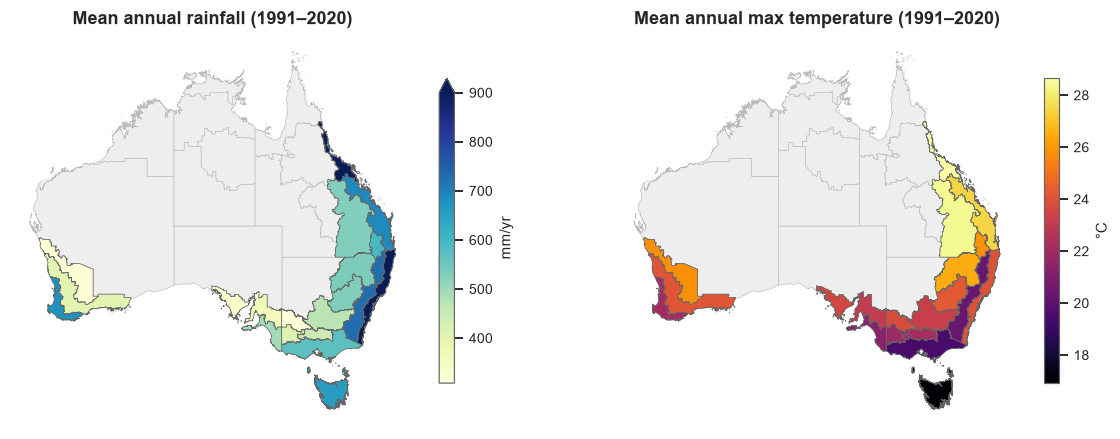

In [6]:
rain_b = blw[blw.variable == "daily_rain"][["aagis_code", "1991-2020"]].rename(
    columns={"1991-2020": "rain_mm"}
)
tmax_b = blw[blw.variable == "max_temp"][["aagis_code", "1991-2020"]].rename(
    columns={"1991-2020": "tmax_c"}
)
fig, axs = plt.subplots(1, 2, figsize=(13, 6))
maps.region_choropleth(
    rain_b, "rain_mm", ax=axs[0], cmap=CMAP_RAINFALL, label="mm/yr",
    title="Mean annual rainfall (1991–2020)", vmax_cap=900,
)
maps.region_choropleth(
    tmax_b, "tmax_c", ax=axs[1], cmap=CMAP_TEMPERATURE, label="°C",
    title="Mean annual max temperature (1991–2020)",
)
savefig(fig, "s02_spatial_climatology_baseline")
plt.show()


**Interpretation.** Rainfall rises from the dry western/interior wheat-belt (WA and eastern SA/VIC Mallee, ~300–400 mm/yr) toward the wetter eastern and coastal margins (the colour bar is capped at 900 mm/yr so the cropping gradient stays legible; tropical QLD coast exceeds it). Max temperature falls monotonically with latitude — hot in the QLD/WA north, coolest in Tasmania — so the broadacre belt spans a wide hot-dry ↔ cool-wet climate space.

### 1.2 Seasonality — when the rain falls

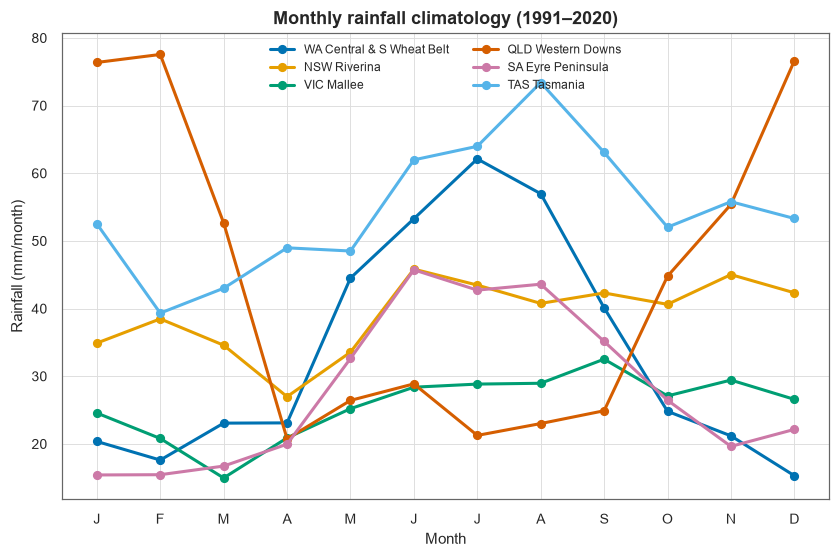

In [7]:
reps = {
    "521": "WA Central & S Wheat Belt",
    "123": "NSW Riverina",
    "221": "VIC Mallee",
    "322": "QLD Western Downs",
    "421": "SA Eyre Peninsula",
    "631": "TAS Tasmania",
}
mr = mon[mon.variable == "daily_rain"]
fig, ax = plt.subplots(figsize=(9, 5.5))
for i, (c, lab) in enumerate(reps.items()):
    s = mr[mr.aagis_code == c].sort_values("month")
    ax.plot(s.month, s.value, marker="o", ms=5, lw=2, color=OKABE_ITO[i], label=lab)
ax.set_xticks(range(1, 13))
ax.set_xticklabels(list("JFMAMJJASOND"))
ax.set_xlabel("Month")
ax.set_ylabel("Rainfall (mm/month)")
ax.set_title("Monthly rainfall climatology (1991–2020)")
ax.legend(ncol=2, fontsize=8)
savefig(fig, "s02_rainfall_seasonality")
plt.show()


**Interpretation.** The southern and western regions (WA Wheat Belt, SA Eyre, VIC Mallee) are **winter-dominant** (Mediterranean; rain peaks May–August, aligning with the winter-crop growing season), while QLD Western Downs is **summer-dominant** (monsoonal; December–February peak). This growing-season timing split is central to how climate stress will map onto wheat/barley/canola vs summer crops (relevant to the optional-crop decision in s05).

### 1.3 Interannual variation & trend — annual rainfall, 1961–2024

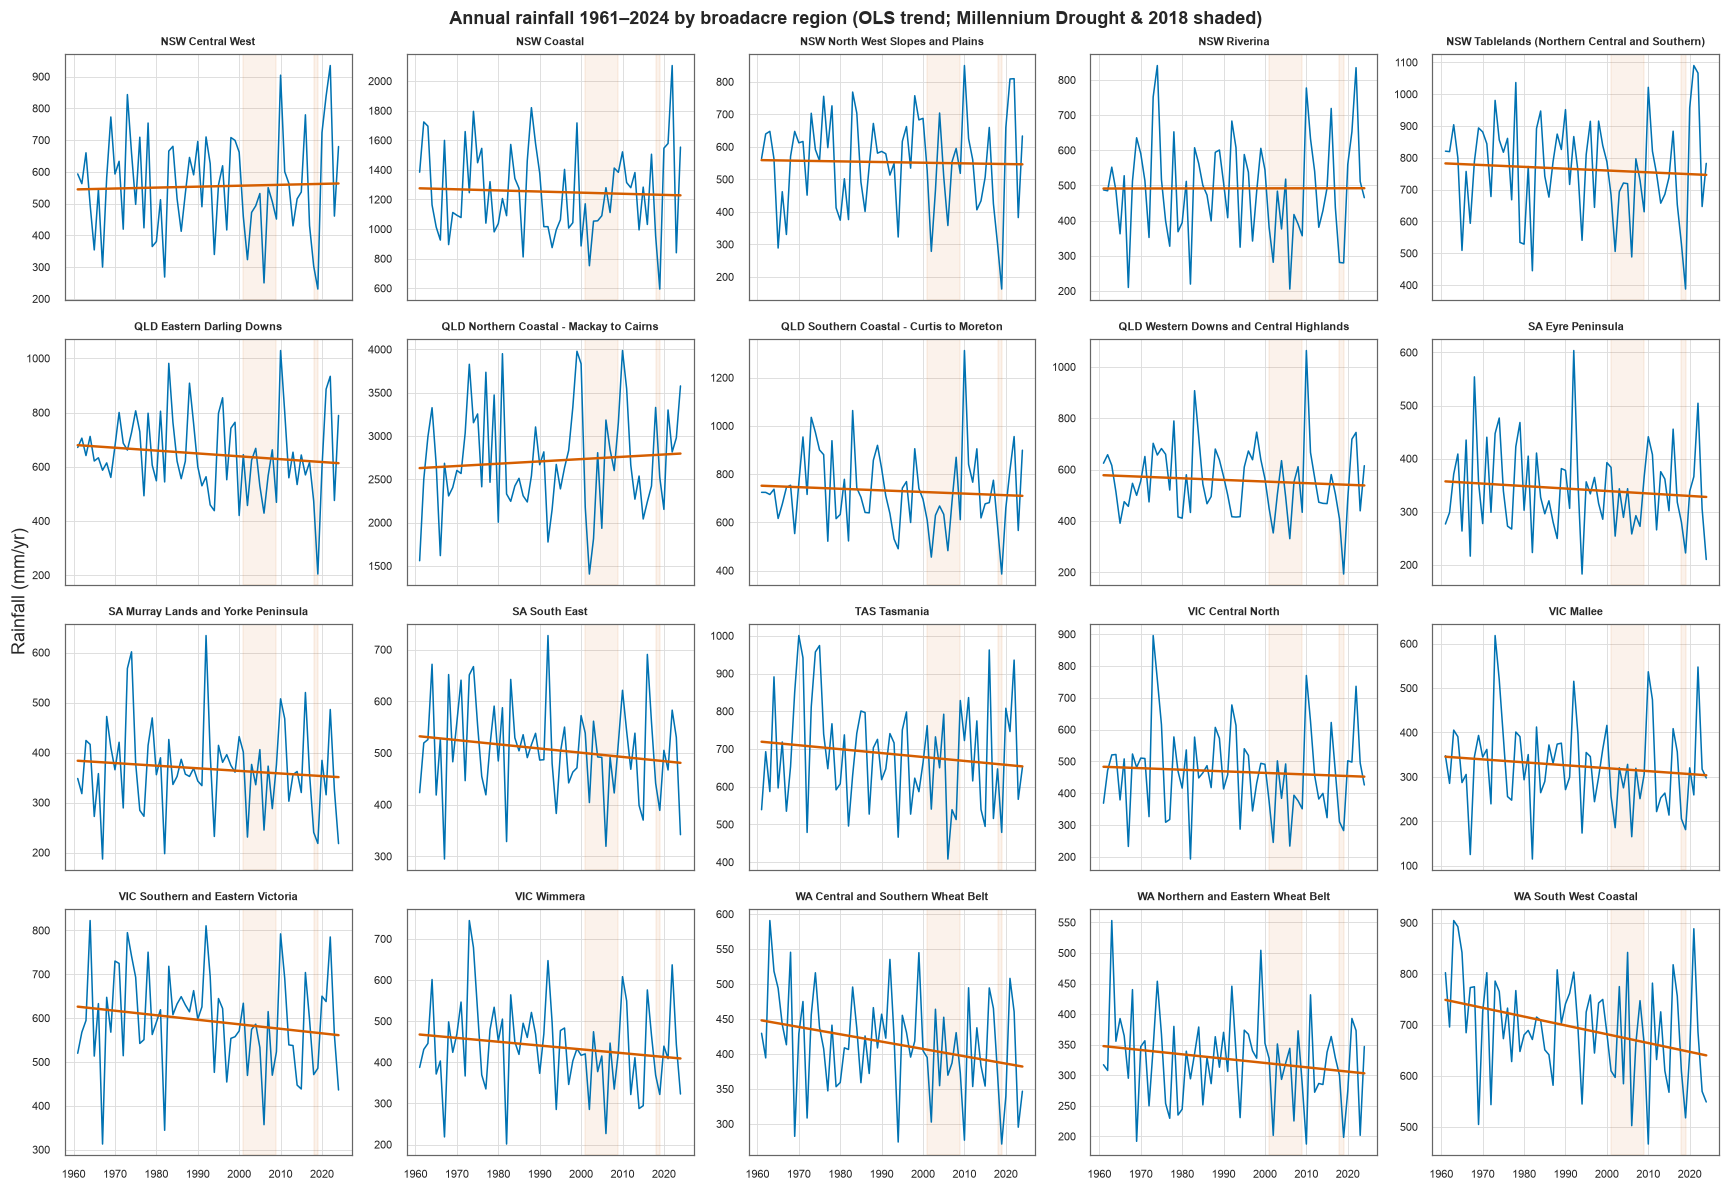

In [8]:
fig, axs = plt.subplots(4, 5, figsize=(16, 11), sharex=True)
for ax, (_, r) in zip(axs.ravel(), broad.iterrows()):
    s = ann[(ann.aagis_code == r.aagis_code) & (ann.variable == "daily_rain")].sort_values(
        "year"
    )
    ax.plot(s.year, s.value, lw=1, color=OKABE_ITO[0])
    b = np.polyfit(s.year, s.value, 1)
    ax.plot(s.year, np.polyval(b, s.year), lw=1.6, color=OKABE_ITO[3])
    for span in [(2001, 2009), (2018, 2019)]:
        ax.axvspan(*span, color="#D55E00", alpha=0.08)
    ax.set_title(r.region_name, fontsize=7.5)
    ax.tick_params(labelsize=7)
for ax in axs.ravel()[len(broad):]:
    ax.axis("off")
fig.suptitle(
    "Annual rainfall 1961–2024 by broadacre region "
    "(OLS trend; Millennium Drought & 2018 shaded)",
    fontweight="bold",
)
fig.supylabel("Rainfall (mm/yr)")
fig.tight_layout()
savefig(fig, "s02_rainfall_series_small_multiples")
plt.show()


**Interpretation.** Year-to-year rainfall variability is large in every region, but the OLS trend is downward across most of the southern cropping belt — clearest in the WA wheat-belt, WA South West Coastal, SA South East, and VIC — while NSW/QLD are flatter and noisier. The Millennium Drought (2001–2009) and 2018 stand out as sustained low-rain episodes in the southeast (carried into the s04 historical-event sanity check).

### 1.4 Warming — max-temperature anomaly vs 1961–1990

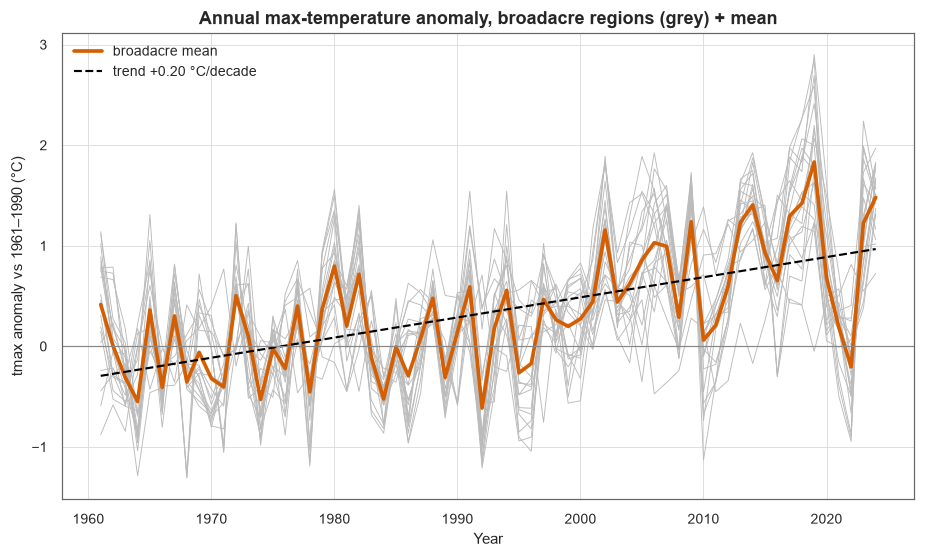

In [9]:
base = (
    bl[(bl.variable == "max_temp") & (bl.baseline == "1961-1990")]
    .set_index("aagis_code").value
)
mt = ann[ann.variable == "max_temp"]
fig, ax = plt.subplots(figsize=(10, 5.5))
series = []
for c in broad.aagis_code:
    s = mt[mt.aagis_code == c].sort_values("year")
    anom = s.value.values - base[c]
    ax.plot(s.year, anom, lw=0.6, color="#BBBBBB")
    series.append(pd.Series(anom, index=s.year.values))
mean_anom = pd.concat(series, axis=1).mean(axis=1)
ax.plot(mean_anom.index, mean_anom.values, lw=2.4, color=OKABE_ITO[3], label="broadacre mean")
b = np.polyfit(mean_anom.index, mean_anom.values, 1)
ax.plot(
    mean_anom.index, np.polyval(b, mean_anom.index), lw=1.4, ls="--",
    color=OKABE_ITO[7], label=f"trend {b[0] * 10:+.2f} °C/decade",
)
ax.axhline(0, color="#888888", lw=0.8)
ax.set_xlabel("Year")
ax.set_ylabel("tmax anomaly vs 1961–1990 (°C)")
ax.set_title("Annual max-temperature anomaly, broadacre regions (grey) + mean")
ax.legend()
savefig(fig, "s02_tmax_anomaly")
plt.show()


**Interpretation.** Max temperature rises in **all 20** broadacre regions; the broadacre-mean anomaly trends at roughly **+0.2 °C/decade** over 1961–2024 (per-region OLS slopes span +0.05 to +0.26 °C/decade), i.e. ~1 °C of warming across the record. The warming is monotonic and spatially coherent — a clean climate-change signal that the yield-linkage models (Pillar 3) will test against production.

### 1.5 How much it varies — interannual rainfall variability

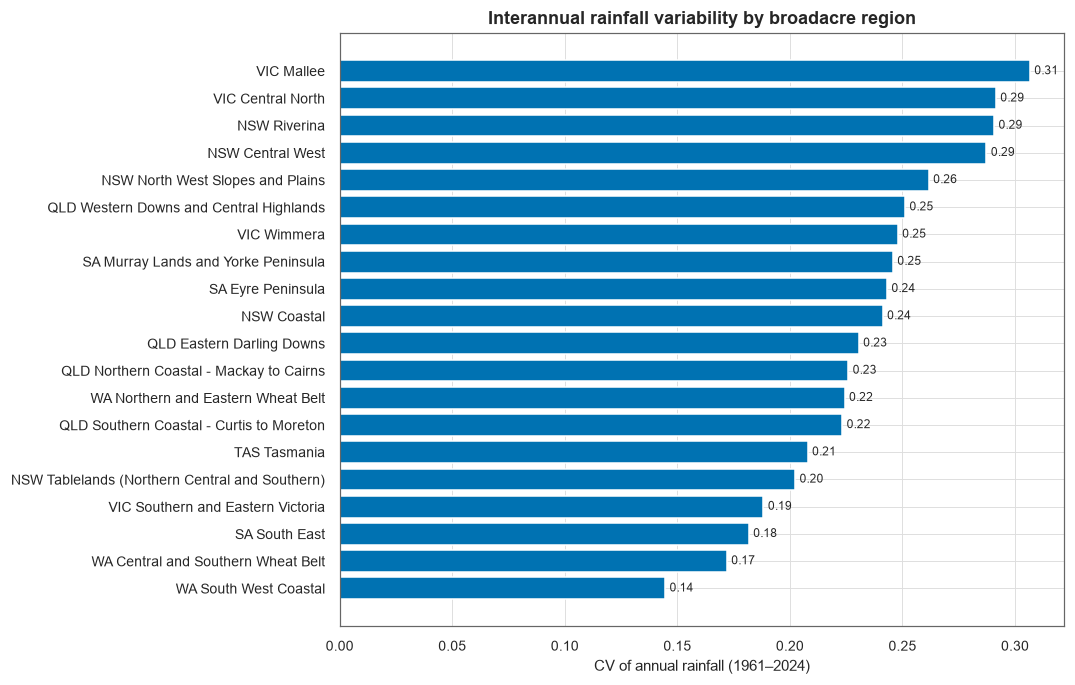

In [10]:
cv = (
    ann[(ann.variable == "daily_rain") & ann.aagis_code.isin(broad_codes)]
    .groupby(["aagis_code", "region_name"]).value.agg(lambda s: s.std() / s.mean())
    .sort_values()
)
fig, ax = plt.subplots(figsize=(8.5, 7))
ax.barh([n for _, n in cv.index], cv.values, color=OKABE_ITO[0])
for i, v in enumerate(cv.values):
    ax.text(v + 0.002, i, f"{v:.2f}", va="center", fontsize=8)
ax.set_xlabel("CV of annual rainfall (1961–2024)")
ax.set_title("Interannual rainfall variability by broadacre region")
savefig(fig, "s02_rainfall_cv")
plt.show()


**Interpretation.** The coefficient of variation of annual rainfall is highest in the dry interior/Mallee (VIC Mallee 0.31, VIC Central North and NSW Riverina ~0.29) and lowest in the Mediterranean south-west (WA South West Coastal 0.14, WA Wheat Belt 0.17, SA South East 0.18). Drier regions are also the *most variable* — a first, purely climatic, signature of where production risk exposure concentrates (to be matched against yield dispersion in s03).

### 1.6 Climate change signal — baseline shift (1991–2020 vs 1961–1990)

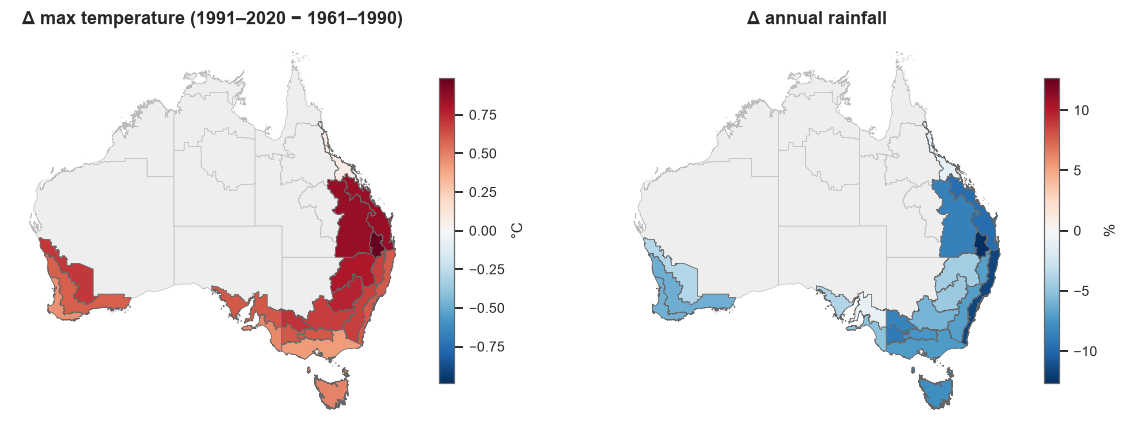

In [11]:
tw = blw[blw.variable == "max_temp"].assign(
    dtmax=lambda d: d["1991-2020"] - d["1961-1990"]
)
rw = blw[blw.variable == "daily_rain"].assign(
    drain=lambda d: 100 * (d["1991-2020"] - d["1961-1990"]) / d["1961-1990"]
)
fig, axs = plt.subplots(1, 2, figsize=(13, 6))
maps.region_choropleth(
    tw[["aagis_code", "dtmax"]], "dtmax", ax=axs[0], cmap=CMAP_ANOMALY, label="°C",
    title="Δ max temperature (1991–2020 − 1961–1990)", diverging=True,
)
maps.region_choropleth(
    rw[["aagis_code", "drain"]], "drain", ax=axs[1], cmap=CMAP_ANOMALY, label="%",
    title="Δ annual rainfall", diverging=True,
)
savefig(fig, "s02_baseline_shift")
plt.show()


**Interpretation.** Between the two WMO reference periods, max temperature rose in **every** broadacre region (median +0.61 °C, up to ~+1.0 °C in inland QLD) and annual rainfall fell in **every** broadacre region (median −6.6%, up to −13% in the east). Warming-and-drying is thus a whole-of-belt shift, not a regional artefact — the central climate premise the risk analysis rests on. (evap_pan's 1961–1990 baseline uses 1970–1990 only; see s02 methodology.)

### 1.7 Climate EDA synthesis (where / when / how much)

- **Where:** a hot-dry interior/western belt vs a cooler-wetter east/south; rainfall ~300 mm/yr (WA/Mallee) to >900 mm/yr (eastern/coastal).
- **When:** winter-dominant rainfall in the south/west (aligned to winter crops), summer-dominant in QLD.
- **How much:** large interannual variability everywhere, highest in the dry interior (CV up to 0.31); a coherent warming trend (~+0.2 °C/decade, 20/20 regions) and a whole-belt drying shift (median −6.6%, 20/20 regions).

These climatic patterns frame the yield analysis in s03 and the historical-event sanity check in s04.

## 2. Yield trends & dispersion (ABARES)

Region-level observed yields for wheat / barley / canola over their reliable windows (wheat/barley 1990+, canola 1994+). Following decision gate ② the survey RSE is shown as a data-quality caveat, not used to weight the descriptive statistics; regions with fewer than 10 reliable years are flagged rather than mixed in. Dispersion uses the *detrended* CV so the rising yield trend does not inflate the year-to-year variability measure.

In [12]:
from src.processing.yield_stats import (
    load_yield,
    region_yield_summary,
    HIGH_RSE,
)

yield_summary = region_yield_summary()
name2code = dict(zip(mapping.region_name, mapping.aagis_code))
wheat = load_yield("wheat")
w_adeq = yield_summary[
    (yield_summary.commodity == "wheat") & yield_summary.adequate
].sort_values("region")
print(f"adequate regions — wheat {w_adeq.shape[0]}, "
      f"barley {yield_summary[(yield_summary.commodity=='barley') & yield_summary.adequate].shape[0]}, "
      f"canola {yield_summary[(yield_summary.commodity=='canola') & yield_summary.adequate].shape[0]}")


adequate regions — wheat 19, barley 19, canola 14


### 2.1 Yield trend — wheat, 1990–2024

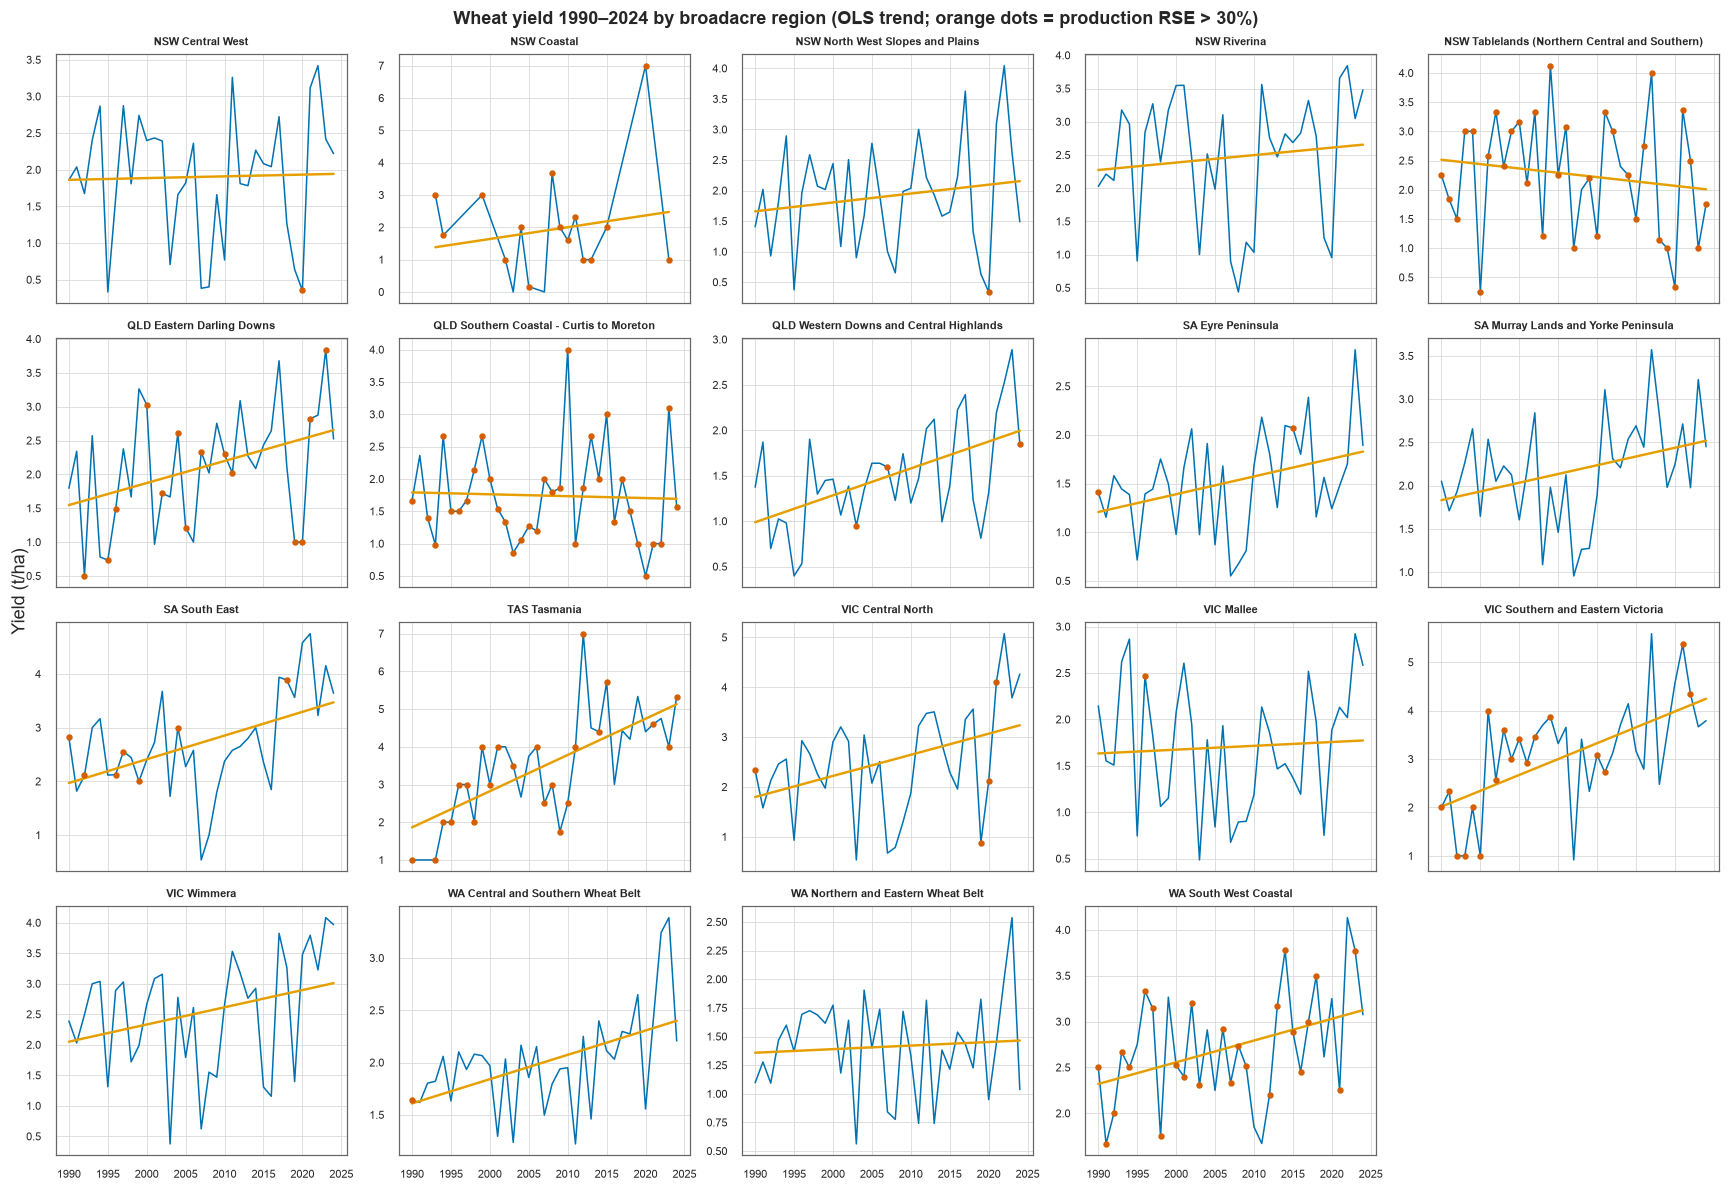

In [13]:
fig, axs = plt.subplots(4, 5, figsize=(16, 11), sharex=True)
for ax, (_, r) in zip(axs.ravel(), w_adeq.iterrows()):
    s = wheat[wheat.region == r.region].sort_values("year")
    hi = s[s.production_rse > HIGH_RSE]
    ax.plot(s.year, s.yield_t_ha, lw=1, color=OKABE_ITO[0])
    ax.scatter(hi.year, hi.yield_t_ha, s=10, color=OKABE_ITO[3], zorder=3)
    b = np.polyfit(s.year, s.yield_t_ha, 1)
    ax.plot(s.year, np.polyval(b, s.year), lw=1.6, color=OKABE_ITO[1])
    ax.set_title(r.region, fontsize=7.5)
    ax.tick_params(labelsize=7)
for ax in axs.ravel()[len(w_adeq):]:
    ax.axis("off")
fig.suptitle(
    "Wheat yield 1990–2024 by broadacre region "
    "(OLS trend; orange dots = production RSE > 30%)",
    fontweight="bold",
)
fig.supylabel("Yield (t/ha)")
fig.tight_layout()
savefig(fig, "s03_wheat_yield_trend")
plt.show()


**Interpretation.** Wheat yield trends **upward in 17 of 19** adequately-covered regions (median +0.23 t/ha/decade) — genetic and agronomic gains lifting the mean even against the warming-and-drying climate of §1. High-RSE survey years (orange) cluster in the marginal high-rainfall/coastal regions, where the series are also noisiest.

### 2.2 Yield distribution by region — wheat

C:\Users\kotae\AppData\Local\Temp\ipykernel_12656\1964077290.py:4: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  bp = ax.boxplot(data, vert=False, tick_labels=order, patch_artist=True, widths=0.6)


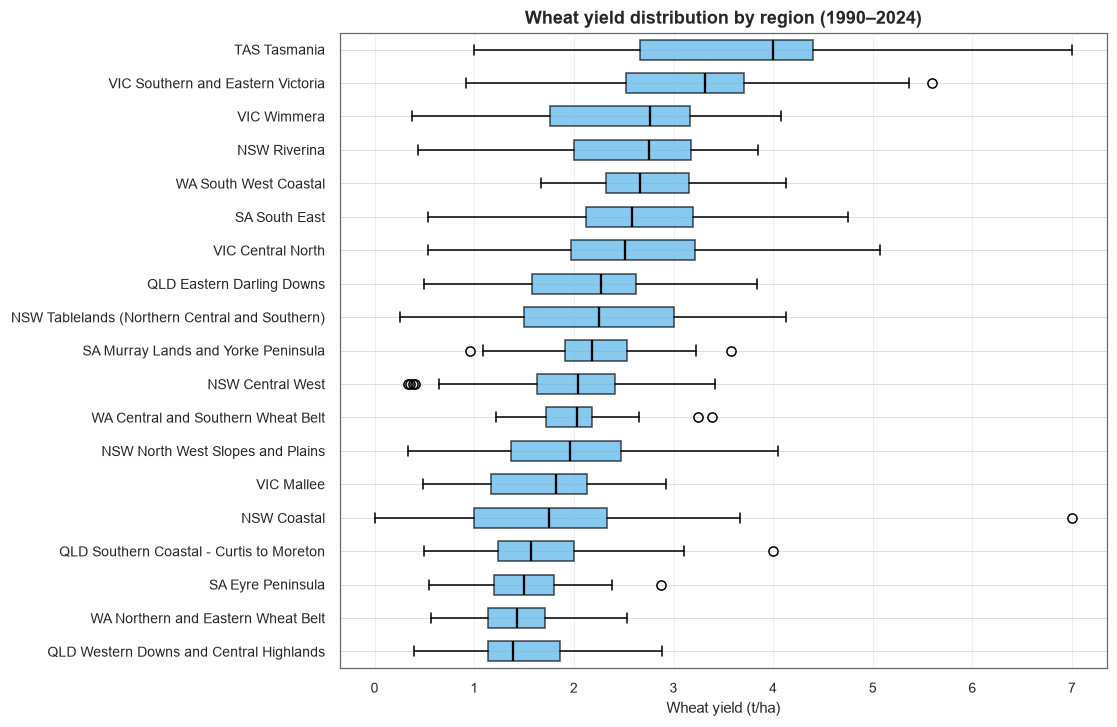

In [14]:
order = w_adeq.sort_values("median_yield").region.tolist()
data = [wheat[wheat.region == rg].yield_t_ha.values for rg in order]
fig, ax = plt.subplots(figsize=(9, 7.5))
bp = ax.boxplot(data, vert=False, tick_labels=order, patch_artist=True, widths=0.6)
for patch in bp["boxes"]:
    patch.set(facecolor=OKABE_ITO[5], alpha=0.7)
for med in bp["medians"]:
    med.set(color=OKABE_ITO[7], lw=1.5)
ax.set_xlabel("Wheat yield (t/ha)")
ax.set_title("Wheat yield distribution by region (1990–2024)")
ax.grid(True, axis="x", alpha=0.5)
savefig(fig, "s03_wheat_yield_distribution")
plt.show()


**Interpretation.** Median wheat yield ranges from ~1.4 t/ha in the dry Mallee/interior to ~3–4 t/ha in the high-rainfall south-east, and the *spread* (whisker length, low-side outliers) is widest exactly where the climate is most variable — the first direct look at where production risk concentrates.

### 2.3 Where wheat yield is most volatile — detrended CV

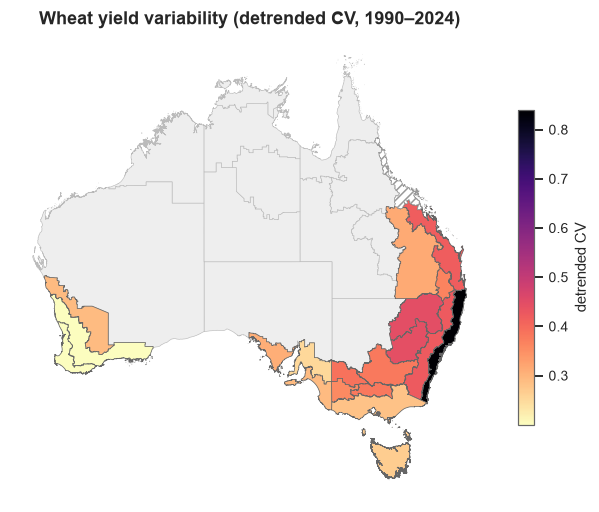

In [15]:
dcv = w_adeq[["region", "detrended_cv"]].copy()
dcv["aagis_code"] = dcv.region.map(name2code)
fig, ax = plt.subplots(figsize=(7, 6.2))
maps.region_choropleth(
    dcv[["aagis_code", "detrended_cv"]], "detrended_cv", ax=ax, cmap="magma_r",
    label="detrended CV", title="Wheat yield variability (detrended CV, 1990–2024)",
)
savefig(fig, "s03_wheat_yield_variability_map")
plt.show()


**Interpretation.** Detrended yield variability is lowest in the WA and SA wheat-belt (CV ~0.20 — reliable Mediterranean winter rain) and highest along the eastern/coastal margin (up to ~0.84 in NSW Coastal). This mirrors the §1 rainfall-variability map: the drier, more rain-variable regions are also the least reliable yielders. (Hatched = a sparse-coverage region excluded from the statistic.)

### 2.4 Lower-tail risk — wheat

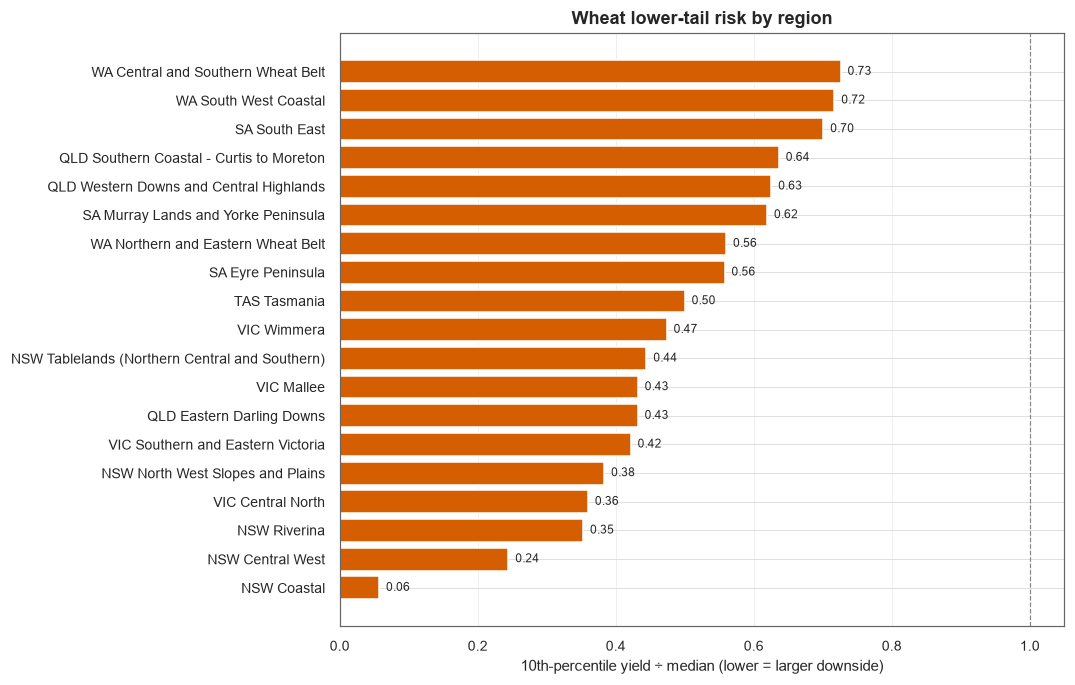

In [16]:
lt = w_adeq.sort_values("p10_over_median")[["region", "p10_over_median"]]
fig, ax = plt.subplots(figsize=(8.5, 7))
ax.barh(lt.region, lt.p10_over_median, color=OKABE_ITO[3])
ax.axvline(1.0, color="#888888", lw=0.8, ls="--")
for i, val in enumerate(lt.p10_over_median):
    ax.text(val + 0.01, i, f"{val:.2f}", va="center", fontsize=8)
ax.set_xlabel("10th-percentile yield ÷ median (lower = larger downside)")
ax.set_title("Wheat lower-tail risk by region")
ax.grid(True, axis="x", alpha=0.5)
savefig(fig, "s03_wheat_lower_tail")
plt.show()


**Interpretation.** In a 1-in-10 bad year the wheat yield falls to roughly **half** the regional median (median ratio ~0.47), and in the most exposed regions to a small fraction of it — the risk that lives in the *lower tail*, not the mean. This lower-tail focus is what motivates the quantile-regression and EVT pillars downstream.

### 2.5 Cross-crop comparison

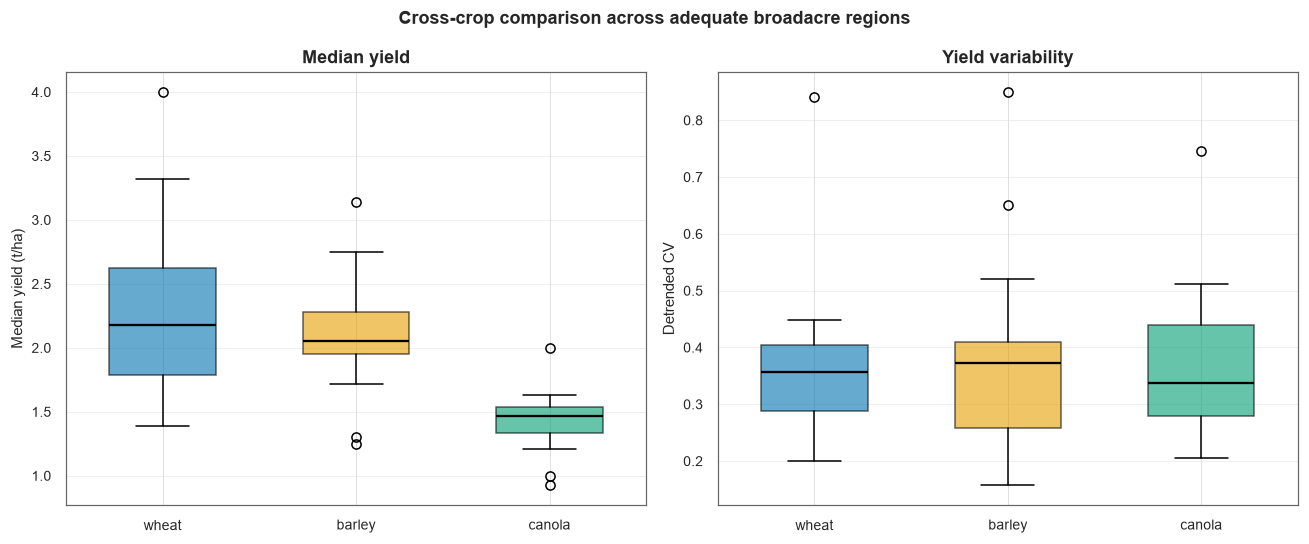

In [17]:
crops = ["wheat", "barley", "canola"]
med = [
    yield_summary[(yield_summary.commodity == c) & yield_summary.adequate].median_yield.values
    for c in crops
]
dcvv = [
    yield_summary[(yield_summary.commodity == c) & yield_summary.adequate].detrended_cv.values
    for c in crops
]
fig, axs = plt.subplots(1, 2, figsize=(12, 5))
for ax, dat, ylab, ttl in [
    (axs[0], med, "Median yield (t/ha)", "Median yield"),
    (axs[1], dcvv, "Detrended CV", "Yield variability"),
]:
    bp = ax.boxplot(dat, tick_labels=crops, patch_artist=True, widths=0.55)
    for i, patch in enumerate(bp["boxes"]):
        patch.set(facecolor=OKABE_ITO[i], alpha=0.6)
    for m in bp["medians"]:
        m.set(color=OKABE_ITO[7], lw=1.5)
    ax.set_ylabel(ylab)
    ax.set_title(ttl)
    ax.grid(True, axis="y", alpha=0.5)
fig.suptitle("Cross-crop comparison across adequate broadacre regions", fontweight="bold")
fig.tight_layout()
savefig(fig, "s03_cross_crop_comparison")
plt.show()


**Interpretation.** Wheat and barley have similar median yields (~2.0–2.2 t/ha) and variability; canola yields lower (~1.4 t/ha, an oilseed) with comparable detrended CV. Barley and canola trend up slightly faster per decade than wheat. The three crops behave as one broadacre system — supporting the tiered treatment (wheat primary; barley/canola generalisation) rather than separate analyses.

### 2.6 Yield EDA synthesis

- **Where / how much:** median yield ~1.4 t/ha (dry interior) to ~3–4 t/ha (high-rainfall SE); detrended variability lowest in the WA/SA wheat-belt (~0.20), highest on the eastern/coastal margin (~0.84) — the same geography as rainfall variability in §1.
- **Trend:** yields rise in ~17/19 regions (~+0.2–0.26 t/ha/decade) despite warming and drying — an agronomic-gain signal to be separated from climate in the models.
- **Risk lives in the tail:** a 1-in-10 year is ~half the median yield, worse in exposed regions — motivating the quantile / EVT pillars.

s04 joins these yields to the §1 climate to test whether rainfall variability explains yield variability, and overlays the known drought/heat events.

## 3. Climate–yield joint view & historical-event sanity

Joining §1 climate to §2 yields at region-year. Both yield and climate are detrended per region before correlating, so the strong yield trend does not manufacture a spurious climate signal. Following decision gate ③ the known drought/heat years are an EDA-level *sanity* overlay with a light quantitative anchor; the formal cross-pillar historical-event validation is Phase 09.

In [18]:
from src.processing.climate_yield import (
    region_linkage,
    build_panel,
    event_year_summary,
)

crops = ["wheat", "barley", "canola"]
linkage = {c: region_linkage(c) for c in crops}


### 3.1 Does a more climate-variable region yield more variably?

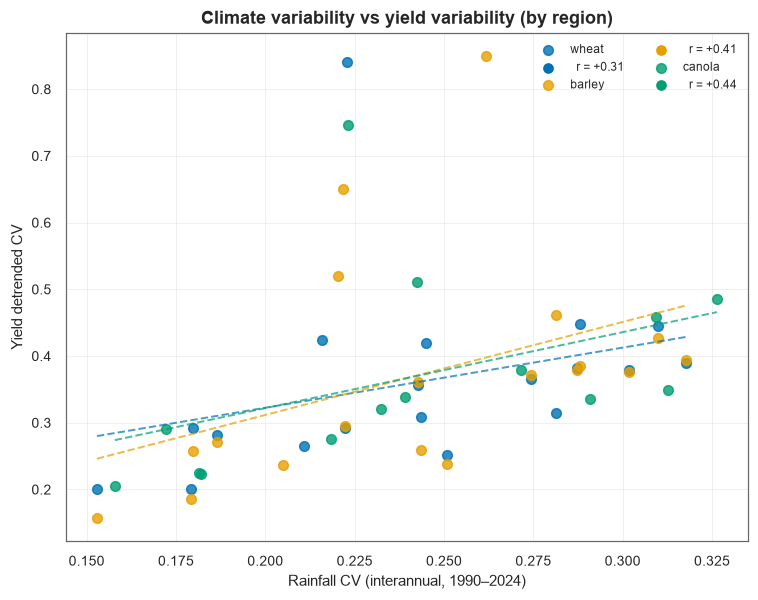

In [19]:
fig, ax = plt.subplots(figsize=(8, 6))
for i, c in enumerate(crops):
    t = linkage[c]
    ax.scatter(t.rain_cv, t.yield_detrended_cv, color=OKABE_ITO[i], alpha=0.8, s=40, label=c)
    r = np.corrcoef(t.rain_cv, t.yield_detrended_cv)[0, 1]
    b = np.polyfit(t.rain_cv, t.yield_detrended_cv, 1)
    xs = np.array([t.rain_cv.min(), t.rain_cv.max()])
    ax.plot(xs, np.polyval(b, xs), color=OKABE_ITO[i], lw=1.3, ls="--", alpha=0.7)
    ax.scatter([], [], color=OKABE_ITO[i], label=f"  r = {r:+.2f}")
ax.set_xlabel("Rainfall CV (interannual, 1990–2024)")
ax.set_ylabel("Yield detrended CV")
ax.set_title("Climate variability vs yield variability (by region)")
ax.grid(True, alpha=0.5)
ax.legend(fontsize=8, ncol=2)
savefig(fig, "s04_climate_yield_cv")
plt.show()


**Interpretation.** Across regions the relationship is **positive but modest** — more rain-variable regions do tend to yield more variably (r = +0.31 wheat, +0.41 barley, +0.44 canola). It is a *structural* signal (climate variability shapes the risk map) but far from deterministic: soil, management and crop mix clearly matter too. The high-CV outliers at low rainfall CV are the marginal high-rainfall/coastal regions.

### 3.2 Year-to-year: annual rainfall vs wheat yield, by region

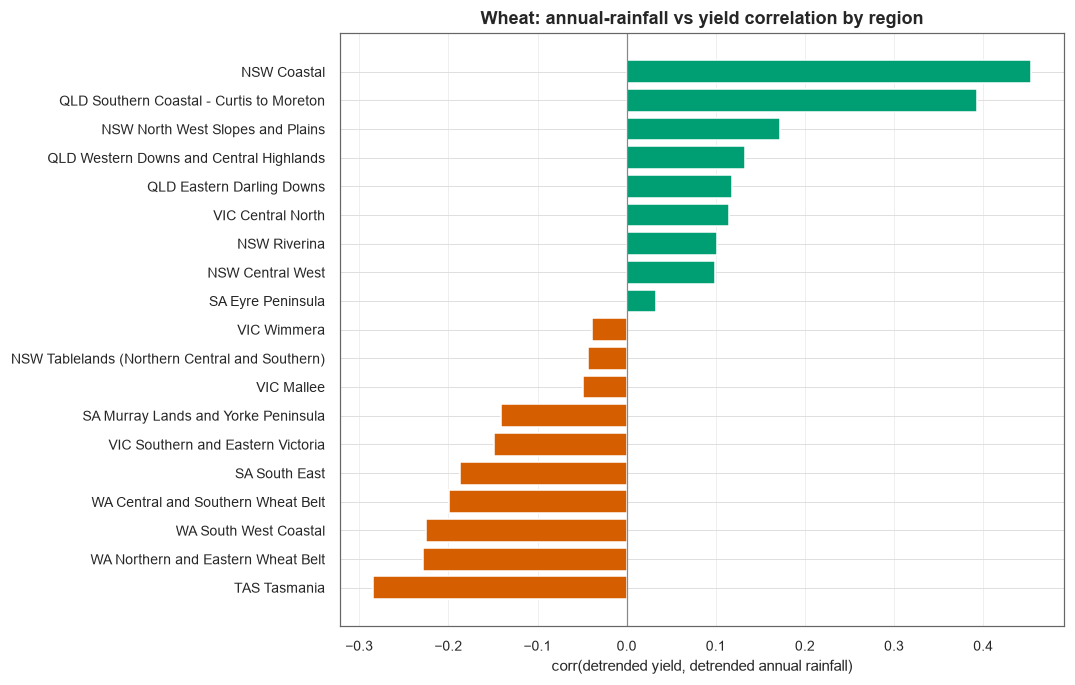

In [20]:
t = linkage["wheat"].sort_values("corr_detr_rain_yield")
fig, ax = plt.subplots(figsize=(8.5, 7))
cols = [OKABE_ITO[2] if v >= 0 else OKABE_ITO[3] for v in t.corr_detr_rain_yield]
ax.barh(t.region, t.corr_detr_rain_yield, color=cols)
ax.axvline(0, color="#888888", lw=0.8)
ax.set_xlabel("corr(detrended yield, detrended annual rainfall)")
ax.set_title("Wheat: annual-rainfall vs yield correlation by region")
ax.grid(True, axis="x", alpha=0.5)
savefig(fig, "s04_rain_yield_correlation")
plt.show()


**Interpretation.** Year-to-year, *annual* rainfall barely tracks wheat yield (median r ≈ −0.04) and is even **negative** in the WA wheat-belt and TAS — where water is not the binding constraint and annual totals mix in non-growing-season rain. This is a decisive EDA result: annual, region-aggregated climate is the wrong resolution for the risk linkage, which **empirically motivates the growing-season / water-balance (SPI, SPEI) and heat (EHF, GDD) indicators of Pillar 1 (Phase 04)** — not just methodological completeness.

### 3.3 Historical-event sanity — wheat

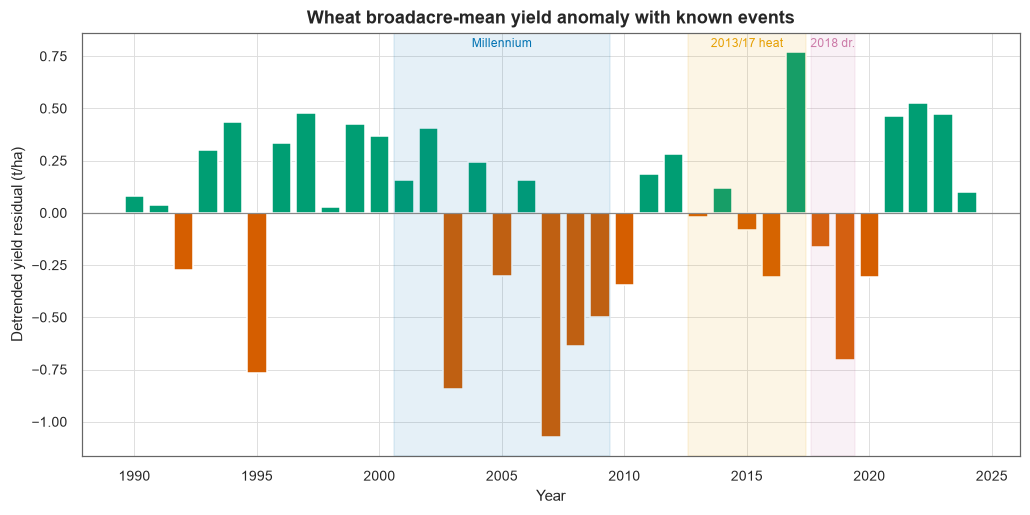

In [21]:
panel = build_panel("wheat")
by_year = panel.groupby("year").resid_yield.mean()
fig, ax = plt.subplots(figsize=(11, 5))
colors = [OKABE_ITO[3] if v < 0 else OKABE_ITO[2] for v in by_year.values]
ax.bar(by_year.index, by_year.values, color=colors, width=0.8)
bands = {
    "Millennium": (2001, 2009, OKABE_ITO[0]),
    "2013/17 heat": (2013, 2017, OKABE_ITO[1]),
    "2018 dr.": (2018, 2019, OKABE_ITO[4]),
}
for lab, (a, b, col) in bands.items():
    ax.axvspan(a - 0.4, b + 0.4, color=col, alpha=0.10)
    ax.text((a + b) / 2, ax.get_ylim()[1] * 0.92, lab, ha="center", fontsize=8, color=col)
ax.axhline(0, color="#888888", lw=0.8)
ax.set_xlabel("Year")
ax.set_ylabel("Detrended yield residual (t/ha)")
ax.set_title("Wheat broadacre-mean yield anomaly with known events")
savefig(fig, "s04_event_timeline")
plt.show()


**Interpretation.** The known **droughts recover cleanly** as below-trend years — the Millennium Drought (deep negatives in 2002/2006–2009) and 2018 — confirming the yield series behaves sensibly. The **2013/2017 "heat" band does not** read as low-yield (2017 was well above trend), because a single-year annual-temperature label does not capture flowering-time heat stress — again pointing to the Pillar 1 heat indices.

### 3.4 Event-year yield anomaly by crop

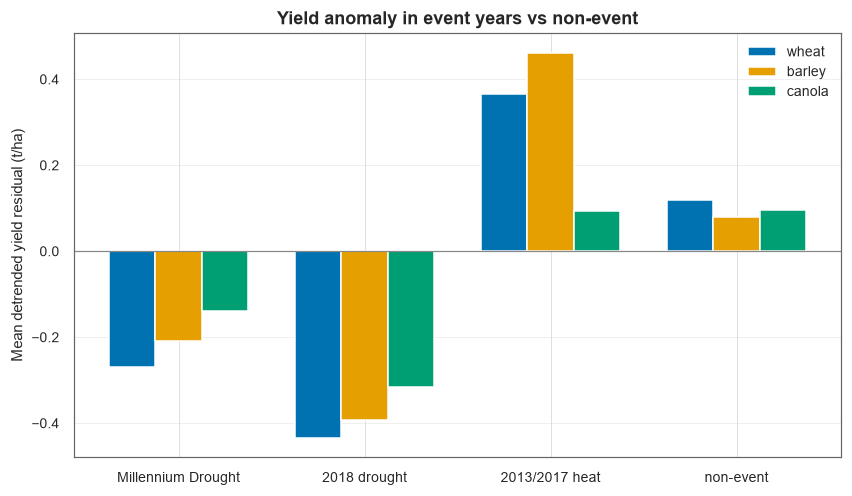

In [22]:
ev = pd.concat([event_year_summary(c) for c in crops])
ev["short"] = ev.event.str.split(" (", regex=False).str[0]
order = ["Millennium Drought", "2018 drought", "2013/2017 heat", "non-event"]
fig, ax = plt.subplots(figsize=(9, 5))
x = np.arange(len(order))
width = 0.25
for i, c in enumerate(crops):
    vals = [ev[(ev.commodity == c) & (ev.short == o)].mean_resid_yield.values[0] for o in order]
    ax.bar(x + (i - 1) * width, vals, width, color=OKABE_ITO[i], label=c)
ax.axhline(0, color="#888888", lw=0.8)
ax.set_xticks(x)
ax.set_xticklabels(order, fontsize=9)
ax.set_ylabel("Mean detrended yield residual (t/ha)")
ax.set_title("Yield anomaly in event years vs non-event")
ax.legend()
ax.grid(True, axis="y", alpha=0.5)
savefig(fig, "s04_event_anomaly")
plt.show()


**Interpretation.** All three crops fall below trend in both droughts (2018 the sharpest, −0.3 to −0.4 t/ha) and sit *above* trend in the 2013/2017 heat years — the drought signal is consistent across the broadacre system while the annual heat label is not a risk marker at this resolution.

### 3.5 Climate–yield synthesis

- **Structural:** rain-variable regions are somewhat more yield-variable (r ≈ 0.3–0.4) — climate shapes the risk map, but is not the whole story.
- **Year-to-year:** annual, region-aggregated rainfall barely predicts yield (and is negative where water is abundant) — the resolution is wrong; **growing-season and water-balance / heat indices (Pillar 1, Phase 04) are empirically necessary.**
- **Events:** droughts recover cleanly as low-yield years; single-year heat labels do not — reinforcing the need for proper heat indicators and the EVT tail focus.

This closes the Phase 03 *where / when / how much* narrative for climate and yield; s05 takes the evidence-led optional-crop decision, s06 consolidates the phase.

## 4. Optional-crop decision (sorghum / cotton)

The scope (§3.2) flags sorghum and cotton as optional crops, to be decided in Phase 03 on the evidence. The decision is data-quality-led and framed by the rainfed-broadacre, climate→yield design.

In [23]:
from src.processing.optional_crops import cotton_variables, sorghum_availability
from src.processing.yield_stats import MIN_YEARS

cotton_vars = cotton_variables()
sorghum = sorghum_availability()
print("cotton variables in FDP regional:", cotton_vars)
print(f"sorghum: broadacre regions with data {int(sorghum.broadacre.sum())}/20, "
      f"with >= {MIN_YEARS} reliable years {int((sorghum.broadacre & sorghum.adequate).sum())}")


cotton variables in FDP regional: ['Cotton receipts ($)']
sorghum: broadacre regions with data 14/20, with >= 10 reliable years 6


### 4.1 Cotton — no region-level yield data

The FDP regional file carries **only `Cotton receipts ($)`** — no area, production or yield. A region-level yield-risk analysis is therefore **impossible**, and cotton is an irrigated crop, outside the rainfed-broadacre framing (scope §2.5). **Cotton is excluded on data grounds.**

### 4.2 Sorghum — a narrow, survey-noisy footprint

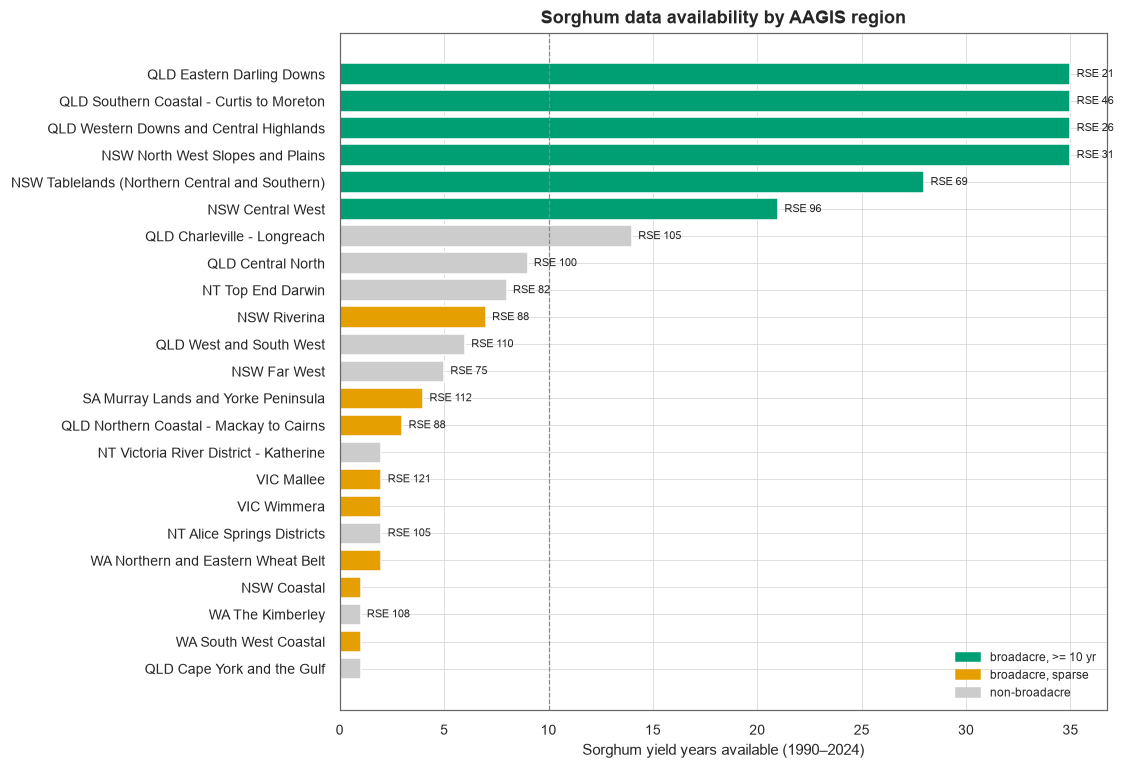

In [24]:
from matplotlib.patches import Patch

sv = sorghum.sort_values("n_years")
colors = [
    OKABE_ITO[2] if (r.broadacre and r.adequate)
    else (OKABE_ITO[1] if r.broadacre else "#CCCCCC")
    for r in sv.itertuples()
]
fig, ax = plt.subplots(figsize=(9, 8))
ax.barh(sv.region, sv.n_years, color=colors)
ax.axvline(MIN_YEARS, color="#888888", ls="--", lw=0.8)
for i, r in enumerate(sv.itertuples()):
    rse = "" if pd.isna(r.median_prod_rse) else f"RSE {r.median_prod_rse:.0f}"
    ax.text(r.n_years + 0.3, i, rse, va="center", fontsize=7)
ax.set_xlabel("Sorghum yield years available (1990–2024)")
ax.set_title("Sorghum data availability by AAGIS region")
ax.legend(
    handles=[
        Patch(color=OKABE_ITO[2], label="broadacre, >= 10 yr"),
        Patch(color=OKABE_ITO[1], label="broadacre, sparse"),
        Patch(color="#CCCCCC", label="non-broadacre"),
    ],
    fontsize=8,
)
savefig(fig, "s05_sorghum_availability")
plt.show()


**Interpretation.** Only **6 broadacre regions** clear the 10-year bar for sorghum, all in the QLD / northern-NSW summer-rainfall belt, and survey error is high (median production RSE ~45 overall, and 69–96 in half of those six, vs 19–32 for the core crops). The footprint is both narrow and noisy, well below the reliability bar the core crops set.

### 4.3 Decision

**Exclude both optional crops for v1.0.**

- **Cotton — excluded (data).** No region-level area/production/yield exists; irrigated, outside the rainfed-broadacre framing.
- **Sorghum — deferred to future work.** Rainfed and yield-derivable, but only 6 broadacre regions have >= 10 reliable years (all QLD/N-NSW summer belt), survey RSE is materially worse than the core crops, and as a *summer* crop it would require its own Pillar 1 growing-season indicators — a separate methodological branch that does not fit the winter-oriented framework this EDA has built.

**Rationale (multi-criteria).** The project's value is methodological breadth and rigor, not crop count; wheat + barley + canola already demonstrate multi-crop generalisation. The binding data constraint is the fixed ~20 broadacre AAGIS regions × ~35 years — sorghum adds neither regions nor years, only ~260 noisy region-years over a subset of the same regions, so it does not relieve the constraint while adding cost across all six downstream pillars and risking dilution of the rigor signal. Sorghum is recorded as a natural future extension: a summer-crop companion study to be added *after* the Pillar 1 growing-season indicators exist (scope §13 flexibility). This resolves the scope §3.2 optional-crop item.

## 5. EDA synthesis — where, when, how much

*To be consolidated at s06.* The Phase 03 exit-criterion narrative across climate and yield.


## Limitations & caveats (running list)

- **ACORN-SAT station truth** is weak for QLD Eastern Darling Downs (no station) and sparse for NSW Central West, VIC Wimmera, VIC Central North, WA South West Coastal.
- **Reliable yield windows:** wheat/barley 1990+, canola 1994+ (RSE gate).
- **evap_pan** is observed only from 1970, so its 1961–1990 baseline uses 1970–1990.
- **Trends here are descriptive (OLS)**, not inferential; formal trend/return-period testing is Pillar 2 (Phase 05).
- **Observed-vs-derived discipline:** ABARES observed yields are the target; AGFD (Phase 09) is validation only.
